# **Autonomous Systems And Bifurcations**

#**Question 1:**
## **Trajectories of an autonomous system:**

 Consider the autonomous system,
 $$ ẋ=sin(x) $$
 Integrate the ODE numerically using Euler’s method with the following initial conditions,
$x(0) = ±1, ±2$. Plot the four trajectories on the same graph. Comment on the asymptotic
$(t → ∞)$ nature of the solutions and explain the results physically.


##Hand Analysis

According to Euler's formula,
$$x(t_0+h)=x(t_0)+h⋅f(t,x)$$
where
$$f(x,t)=sin(x)$$

i.e. $$x(t_0+h)=x(t_0)+h⋅sinx$$
We have been given initial values, $x(0)=0,±1,±2$

At fixed points, $$sin(x)=0$$

So the points are at $x=k\pi$ where $k=....-2,-1,0,1,2...$

In given range from $-2$ to $2$, the fixed points are $-\pi,0,\pi$

$$f'(x^*)=cos(x^*)$$

For $x^*=-\pi$,$$cos(-\pi)=-1$$

So it is **stable**.

For $x^*=\pi$,$$cos(\pi)=-1$$

So it is **stable**.

For $x^*=0$,
$$cos(0)=1$$
Hence it is **unstable**.

When $x(0)=+1,+2$,
it starts between $0$ and $+\pi$. Hence the trajectories move towards $\pi$.

On the other hand, the trajectories of $x(0)=-1,-2$ are attracted towards $-\pi$.

In both case , trajectories are repelled from $0$.

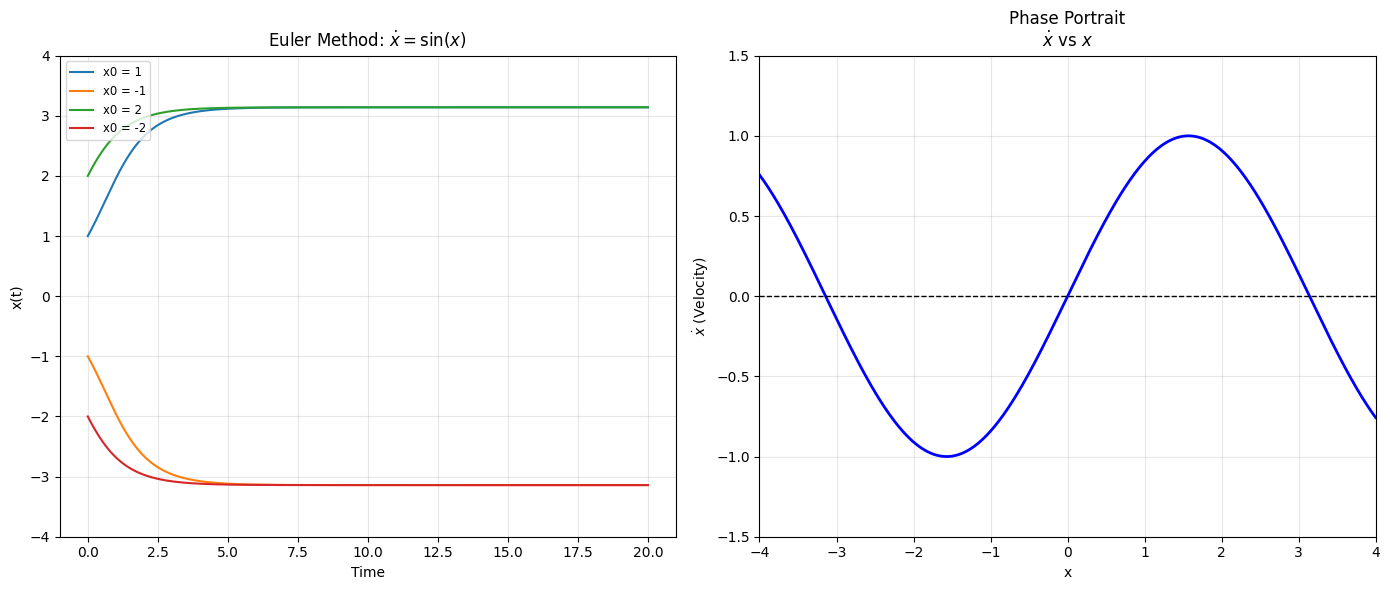

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
T = 20
t = np.arange(0, T, dt)

initial_conditions = [1, -1, 2, -2]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for x0 in initial_conditions:
    x = np.zeros(len(t))
    x[0] = x0

    for i in range(len(t) - 1):
        x[i+1] = x[i] + dt * np.sin(x[i])

    ax1.plot(t, x, label="x0 = " + str(x0))

ax1.set_xlabel("Time")
ax1.set_ylabel("x(t)")
ax1.set_title("Euler Method: $\\dot{x} = \\sin(x)$")
ax1.set_ylim(-4, 4)
ax1.legend(loc='upper left', fontsize='small')
ax1.grid(True, alpha=0.3)

x_vals = np.linspace(-4, 4, 400)
x_dot = np.sin(x_vals)

ax2.plot(x_vals, x_dot, 'b-', lw=2)
ax2.axhline(0, color='black', linestyle='--', lw=1)

ax2.set_xlabel("x")
ax2.set_ylabel("$\\dot{x}$ (Velocity)")
ax2.set_title("Phase Portrait\n$\\dot{x}$ vs $x$")
ax2.set_xlim(-4, 4)
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Observations
###Asymptotic Behaviour
1) As $t$ approaches infinity, the trajectories of $x(0)=1$ and $x(0)=2$ increase and approach $π$
2) On the other hand,the trajectories of $x(0)=-1$ and $x(0)=-2$ decrease and approach $-π$

###Physical Behaviour
The reason for the asymptotic behaviour is due to the presence of fixed points where $ẋ=0$ .
Here those points are $0$,$π$ and $-π$ in the given range.

For $x^*=0$

  $$ f'(0)=cos(0)=1>0 $$
  Hence it is **unstable** and trajectories move away from it.

For both $x^*=π$ and $x^*=-π$

  $$ f'(π)=f'(-π)=-1\lt0 $$
  
  Hence both are **stable** and trajectories move towards them.

Therefore in this case $x(0)=1$ and $x(0)=2$ move towards $π$ while $x(0)=-1$ and $x(0)=-2$ move towards $-π$

#**Question 2:**
## **Confirming Bifurctions from trajectories:**
Consider the autonomous systems,

$(a)$ $ẋ=r-x^2$ This system undergoes a saddle-node bifurcation at $r = 0$. Using Euler's method, integrate the equation numerically and show that the bifurcation takes place by analyzing the trajectories for $r = -1.1, 0, 1.1$. Choose initial conditions carefully.
Using matplotlib (or similar) to make a slider whereby you can adjust the value of $r$
and see the trajectories changing in real time

$(b)$ $ẋ=rx-x^2$. This system undergoes a transcritical bifurcation at $r = 0$. Do the same
exercise as the previous part.

##Hand Analysis for $(a)$

For $ẋ=r-x^2$, we need to find the fixed points and their stability at $r\lt0,r=0,r \gt 0$.

For $r\lt0$, $$ẋ=r-x^2\lt0$$

Therefore, no fixed points exist and all trajectories move in negative direction.

For $r=0$, $$ẋ=-x^2$$
Hence for $ẋ=0$,$$x=0$$ is a fixed point. Also it is **neither completely stable nor completely unstable**.Hence some trajectories should move towards $x=0$ while others will get repulsed.

For $r\gt0$, when $ẋ=0$
$$x=\pm\sqrt{r}$$
Now, $$f'(x) = \frac{d}{dx}(r-x^2)$$
$$=-2x$$

For $x^*=\sqrt{r}$,
$$f'(\sqrt{r})=-2\sqrt{r}\lt0$$
Hence, at $x=\sqrt{r}$, the trajectories are attracted towards it and it is **stable**.

For $x^*=-\sqrt{r}$,
$$f'(-\sqrt{r})=-2\sqrt{r}\gt0$$
Hence, at $x=-\sqrt{r}$, the trajectories are repelled from it and it is **unstable**.

So, for $r>0$ there are two fixed points.

Hence the number of fixed points change by changing the value of $r$ in this case. Therefore, it is a $saddle\  node$ bifurcation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

def saddle_node_colab(r):
    t_end = 10
    h = 0.01
    t = np.arange(0, t_end, h)

    initial_conditions = [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    for x0 in initial_conditions:
        x = np.zeros_like(t)
        x[0] = x0

        for i in range(1, len(t)):
            if abs(x[i-1]) > 10:
                x[i] = x[i-1]
            else:
                change = r - x[i-1]**2
                x[i] = x[i-1] + h * change

        ax1.plot(t, x, label=f'x0={x0}')

    ax1.set_title(f"Trajectories\n$\\dot{{x}} = r - x^2$ (r = {r:.2f})")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("x")
    ax1.set_ylim(-4, 4)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right', fontsize='small', ncol=2)
    x_vals = np.linspace(-4, 4, 400)
    x_dot = r - x_vals**2

    ax2.plot(x_vals, x_dot, 'b-', lw=2)
    ax2.axhline(0, color='black', linestyle='--', lw=1)

    ax2.set_title("Phase Portrait\n$\\dot{x}$ vs $x$")
    ax2.set_xlabel("x")
    ax2.set_ylabel("$\\dot{x}$ (Velocity)")
    ax2.set_ylim(-4, 4)
    ax2.set_xlim(-3, 3)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(saddle_node_colab,
         r=widgets.FloatSlider(min=-1.1, max=1.1, step=0.1, value=0.0));

interactive(children=(FloatSlider(value=0.0, description='r', max=1.1, min=-1.1), Output()), _dom_classes=('wi…

##Observations for $(a)$

1. At $r=-1.1$, all trajectories move to $-\infty$ . There are **no fixed points** as $r-x^2 < 0$ .
2. At $r=0$, trajectories starting from less than $0$ move towards $-\infty$ while others move towards $0$. This is because there is a **neither fully attractive nor fully repulsive** fixed point at $x=0$. Here, $ẋ=-x^2$.
3. At $r=1.1$, $x=\pm\sqrt{r}$ . In this case trajectories will move towards $x=1.05$ and away from $x=-1.05$. Thus, there are **two fixed points**.

By the above three points , we can conclude $(a)$ undergoes a **saddle node bifurcation**.

##Hand Analysis for $(b)$

$$ẋ=rx-x^2$$

For $ẋ=0$,
$$x(r-x)=0$$

Hence, regardless of $r$, there are two fixed points,$i.e$,
$$x=0\ and\;x=r$$

Now, $$f'(x)=\frac{d}{dx}(rx-x^2)$$
$$=r-2x$$

For $x^*=0$,
$$f'(x^*)=r$$
Here, for **$r>0$, the point is unstable** but for **$r\lt0$ the point becomes stable**.

While for $x^*=r$,
$$f'(x^*)=-r$$
Now, here for $r>0$, **the point is stable** but for $r\lt0$ **the point becomes unstable**.

For $r=0$, both points become one and the stability is neither completely stable nor unstable.

Thus, from the above analysis we can conclude that the stability of the fixed points is exchanged at $r=0$ so this is a $transcritical$ bifurcation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

def transcritical_colab(r):
    t_end = 10
    h = 0.01
    t = np.arange(0, t_end, h)

    initial_conditions = [-0.5, 0.1, 0.5, 1.5, -1.5, -3, -4, 4, 5, 3, 2, -2]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for x0 in initial_conditions:
        x = np.zeros_like(t)
        x[0] = x0

        for i in range(1, len(t)):
            if abs(x[i-1]) > 10:
                x[i] = x[i-1]
            else:
                change = r*x[i-1] - x[i-1]**2
                x[i] = x[i-1] + h * change

        ax1.plot(t, x, label=f'x0={x0}')

    ax1.set_title(f"Trajectories\n$\\dot{{x}} = rx - x^2$ (r = {r:.2f})")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("x")
    ax1.set_ylim(-3, 3)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right', fontsize='small', ncol=2)

    x_vals = np.linspace(-4, 4, 400)
    x_dot = r * x_vals - x_vals**2

    ax2.plot(x_vals, x_dot, 'b-', lw=2)
    ax2.axhline(0, color='black', linestyle='--', lw=1)

    ax2.set_title("Phase Portrait\n$\\dot{x}$ vs $x$")
    ax2.set_xlabel("x")
    ax2.set_ylabel("$\\dot{x}$ (Velocity)")
    ax2.set_ylim(-4, 4)
    ax2.set_xlim(-3, 3)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(transcritical_colab,
         r=widgets.FloatSlider(min=-2.0, max=2.0, step=0.1, value=0));

interactive(children=(FloatSlider(value=0.0, description='r', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

## Observations for $(b)$

1. At $r=-1.1$, the fixed points are present at $x=0$ and $x=-1.1$. The trajectories move towards $x=0$ so it is **stable** while they move away from $x=-1.1$ so it is **unstable**.

2. At $r=0$, the fixed point is at $x=0$ and it is attractive for trajectories with $x(0)\ge0$ and repulsive for $x(0)\lt0$

3. At $r=1.1$ , the fixed points are present at $x=0$ and $x=1.1$. The trajectories move away from $x=0$ so it is **unstable** while they move towards $x=1.1$ so it is **stable**.

From the above points, we conclude that $(b)$ undergoes **transcritical** bifurcation at $r=0$

# **Question 3:**
##   **Duffing Oscillator with low acceleration:**

 Consider the system,

 $$ẋ=r-αx- βx^3 $$

 Analyse the fixed points, stability and possible bifurcations of this system, with $r$ being
the tunable parameter. Simulate this system similar to the preceding questions. Note
that there can be different combinations of the ranges of the parameters $([α > 0 , β > 0],
[α > 0 , β < 0]$ etc). In addition, this system (which is motivated by the model of a forced
oscillator in a viscous medium) is encountered in many areas of science and engineering
and you should read at least qualitatively about this model. This information is readily
available, for example, on Wikipedia. For example, what is the origin of the $x^3$ term?

##Hand Analysis

$$ẋ=r-αx- βx^3$$
Let $ẋ=0$,
$$αx+ βx^3 -r=0$$
The equation has three roots,$i.e$, three fixed points.

Also,
$$f'(x)=-α-3βx^2$$

###Case 1: $α>0$, $β>0$

$$f'(x^*)\lt0$$
where $x^*$ is a fixed point.

Therefore all fixed points will be **stable**.

$$ẋ=r-αx- βx^3$$
As $x→-∞$, $ẋ→∞$

As $x→∞$, $ẋ→-∞$

So the function is a strictly decreasing function, meaning it will have a single stable fixed point where $ẋ=0$

There are no bifurcations as number of fixed points and their stablity is not affected. For all values of $r$, there is going to be only **one stable fixed point**.

###Case 2: $α<0$, $β<0$

$$f'(x^*)\gt0$$
where $x^*$ is a fixed point

So all fixed points are unstable.

$$ẋ=r-αx- βx^3$$
As $x→-∞$, $ẋ→-∞$

As $x→∞$, $ẋ→∞$

So the function is strictly increasing , meaning it will have a single unstable fixed point at $ẋ=0$

There are no bifurcations as number of fixed points and their stablity is not affected. For all values of $r$, there is going to be only **one unstable fixed point**.

###Case 3: $α>0$, $β<0$

$$ẋ=r-αx- βx^3$$
$x→∞$, $ẋ→∞$ and $x→-∞$, $ẋ→-∞$ as the $βx^3$ term dominates over large values of $x$.

Let $b=-β$,
$$f'(x^*)=-α+3b(x^*)^2$$
$$-α+3b(x^*)^2=0$$
$$x^*=\pm\sqrt{\frac{α}{3b}}$$

This two points are where the $f(x)$ bends

Hence there are three fixed points. First point is  **unstable**, second is **stable** and the third is again **unstable**.

For bifurcation,$f(x^*)=0$ and $f'(x^*)=0$

$$f(x)=0$$
$$r-αx^*+ bx^*\frac{α}{3b}=0$$
$$r=\frac{2αx^*}{3}$$
$$r_c=\pm\frac{2α^{3/2}}{3\sqrt{3b}}$$

At $|r|>r_c$,
the number of fixed points become one.

For $|r|\lt r_c$, the number of fixed points is 3.

This is a **saddle node bifurcation**.

###Case 4: $α<0$, $β>0$

$$ẋ=r-αx- βx^3$$
$x→∞$, $ẋ→-∞$ and $x→-∞$, $ẋ→∞$ as the $βx^3$ term dominates over large values of $x$.

Let $a=-α$,
$$f'(x)=a-3βx^2$$
$$a-3βx^2=0$$
$$x=\pm\sqrt{\frac{a}{3β}}$$

This two points are where the $f(x)$ bends

Hence there are three fixed points. First point is  **stable**, second is **unstable** and the third is again **stable**.

For bifurcation,$f(x^*)=0$ and $f'(x^*)=0$

$$f(x)=0$$
$$r+ax- βx\frac{a}{3β}=0$$
$$r=\frac{2ax}{3}$$
$$r_c=\pm\frac{2a^{3/2}}{3\sqrt{3β}}$$

At $|r|>r_c$,
the number of fixed points become one.

For $|r|\lt r_c$, the number of fixed points is 3.

This is a **saddle node bifurcation**.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def duffing_analysis(r, alpha, beta):
    t_end = 10
    h = 0.01
    t = np.arange(0, t_end, h)
    initial_conditions = np.linspace(-3, 3, 10)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for x0 in initial_conditions:
        x = np.zeros_like(t)
        x[0] = x0
        for i in range(1, len(t)):

            if abs(x[i-1]) > 10:
                x[i] = np.nan
            else:
                dx = r - alpha*x[i-1] - beta*(x[i-1]**3)
                x[i] = x[i-1] + h * dx

        ax1.plot(t, x, alpha=0.6)

    ax1.set_title(f"Trajectories\n$\\dot{{x}} = {r} - ({alpha})x - ({beta})x^3$")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("x")
    ax1.set_ylim(-4, 4)
    ax1.grid(True, alpha=0.3)

    x_vals = np.linspace(-4, 4, 400)
    x_dot = r - alpha * x_vals - beta * (x_vals**3)

    ax2.plot(x_vals, x_dot, 'b-', lw=2)
    ax2.axhline(0, color='black', linestyle='--', lw=1)

    ax2.set_title("Phase Portrait\n$\\dot{x}$ vs $x$")
    ax2.set_xlabel("x")
    ax2.set_ylabel("$\\dot{x}$ (Velocity)")
    ax2.set_ylim(-5, 5)
    ax2.set_xlim(-4, 4)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(duffing_analysis,
         r=FloatSlider(min=-5.0, max=5.0, step=0.1, value=0.0, description='r'),
         alpha=FloatSlider(min=-1.0, max=1.0, step=0.1, value=1.0, description='α'),
         beta=FloatSlider(min=-1.0, max=1.0, step=0.1, value=1.0, description='β')
        );

interactive(children=(FloatSlider(value=0.0, description='r', max=5.0, min=-5.0), FloatSlider(value=1.0, descr…

##Observations

1. For $α\lt0$ and $β\lt0$, there is only a **single unstable fixed point**.

2. For $α\gt0$ and $β\gt0$, there is only a **single stable fixed point**.

3. For $α\gt0$ and $β\lt0$, saddle node bifurcation can be seen where three fixed points (**unstable-stable-unstable**) turn into single **unstable** point.

4. For $α\lt0$ and $β\gt0$, saddle node bifurcation can be seen where three fixed points (**stable-unstable-stable**) turn into single **stable** point.